In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
import os
os.environ["KERAS_BACKEND"] = "jax"

import bayesflow as bf

INFO:2025-11-14 16:36:21,988:jax._src.xla_bridge:822: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:bayesflow:Using backend 'jax'


In [5]:
from simulators.benchmarks import DDM

In [6]:
num_obs = 500
num_train = 10000
num_val = 100
epochs = 100
batch_size = 32

### Workflow

In [7]:
simulator = DDM()

In [8]:
samples = simulator.sample(batch_size=batch_size)

In [9]:
adapter = (
    bf.Adapter()
    .convert_dtype("float64", "float32")
    .drop(["decay"])
    .concatenate(["v", "a", "tau", "s_v", "s_tau"], axis=-1, into="inference_variables")
    .concatenate(["rts", "choices"], into="summary_variables")
)

In [10]:
summary_network = bf.networks.SetTransformer(summary_dim=16, seed_dim=32)
inference_network = bf.networks.FlowMatching()

In [11]:
workflow = bf.BasicWorkflow(
    inference_network=inference_network,
    summary_network=summary_network,
    simulator=simulator,
    adapter=adapter,
    checkpoint_filepath=f"../checkpoints/ddm_online_{epochs}.ckpt",
)

Existing checkpoints can _not_ be restored/loaded using this workflow. Upon refitting, the checkpoints will be overwritten. To load the stored approximator from the checkpoint, use approximator = keras.saving.load_model(...)


In [12]:
validation_data = workflow.simulate(500)

In [13]:
history = workflow.fit_online(
    epochs=epochs,
    batch_size=batch_size,
    num_batches_per_epoch=100,
    validation_data=validation_data
)

INFO:bayesflow:Fitting on dataset instance of OnlineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 27s 118ms/step - loss: 5.1963 - val_loss: 2.0072
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 66ms/step - loss: 2.0374 - val_loss: 1.3800
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 90ms/step - loss: 1.6812 - val_loss: 1.5070
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 96ms/step - loss: 1.4841 - val_loss: 1.2340
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 127ms/step - loss: 1.4324 - val_loss: 1.2933
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 128ms/step - loss: 1.2067 - val_loss: 1.0621
Epoch 7/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 133ms/step - loss: 1.1591 - val_loss: 1.0031
Epoch 8/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 149ms/step - loss: 1.0657 - val_loss: 1.0074
Epoch 9/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 139ms/step - loss: 1.0455 - val_loss: 0.9108
Epoch 10/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 148ms/step - loss: 1.0040 - val_loss: 0.9650
Epoch 11/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 18s 183ms/step - loss: 0.9546 - val_loss: 0.8707
Epoch 12/100


INFO:bayesflow:Training is now finished.
            You can find the trained approximator at '../checkpoints/ddm_online_100.ckpt/model.model.keras'.
            To load it, use approximator = keras.saving.load_model(...).


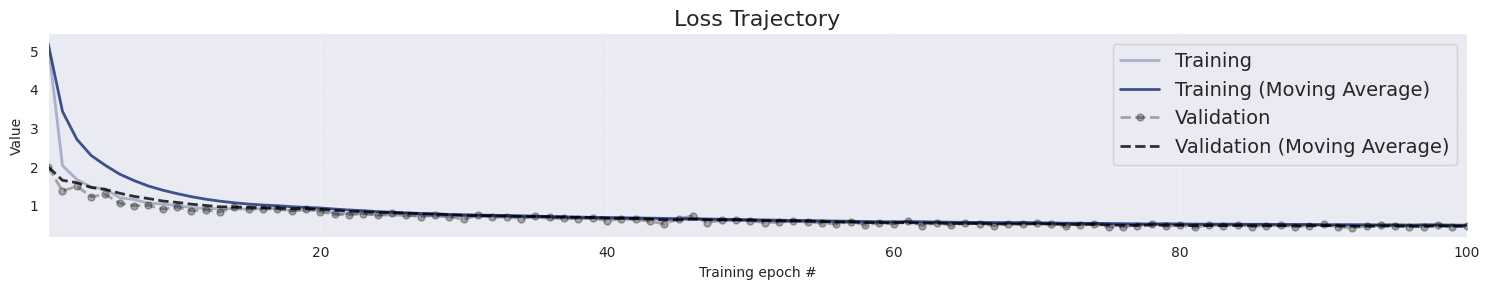

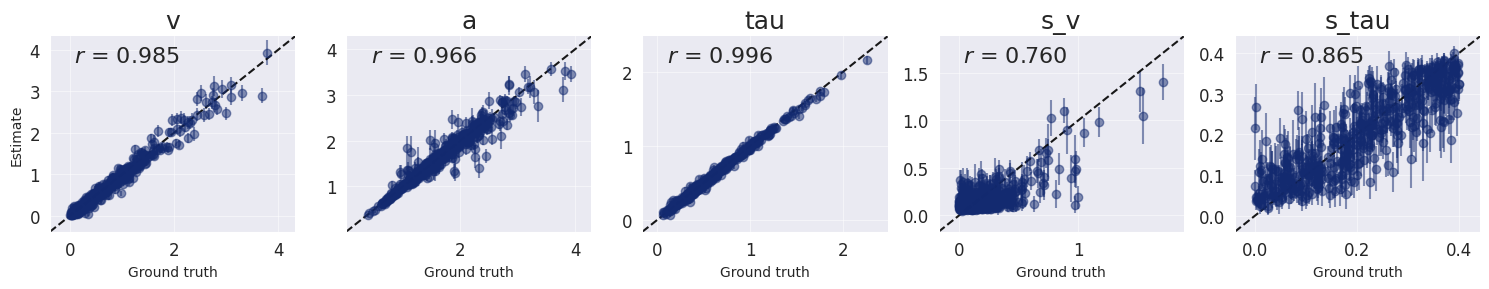

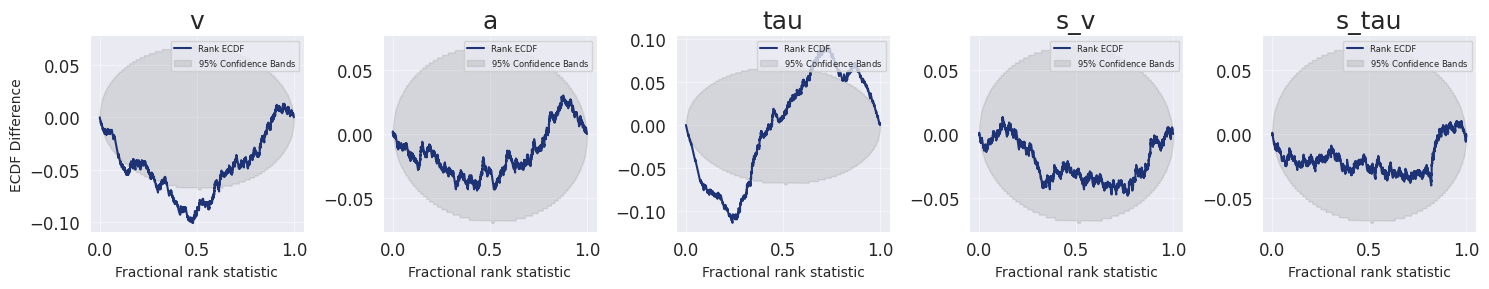

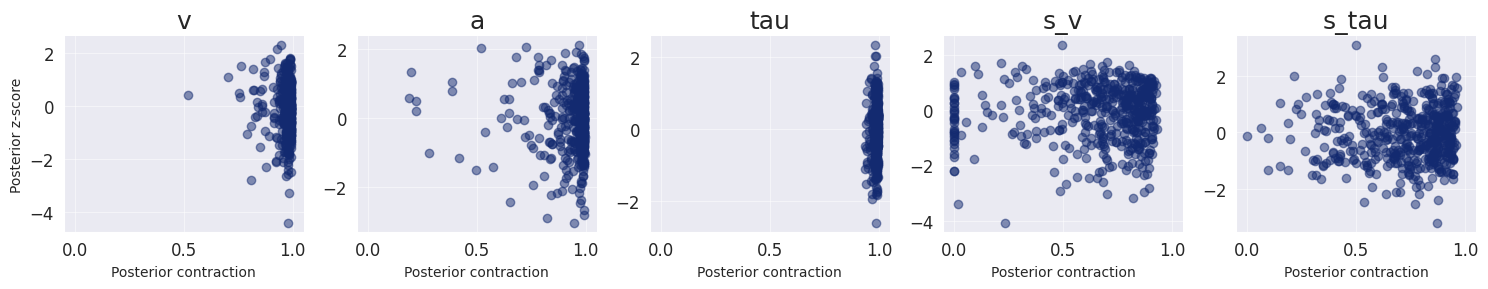

In [14]:
fig = workflow.plot_default_diagnostics(
    test_data=validation_data,
    variable_names=["v", "a", "tau", "s_v", "s_tau"],
    loss_kwargs={"figsize": (15, 3), "label_fontsize": 10},
    recovery_kwargs={"figsize": (15, 3), "label_fontsize": 10},
    calibration_ecdf_kwargs={"figsize": (15, 3), "legend_fontsize": 6, "difference": True, "label_fontsize": 10},
    z_score_contraction_kwargs={"figsize": (15, 3), "label_fontsize": 10}
)